In [1]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import seaborn as sns
import xarray as xr
import tqdm
import pathlib
import cmocean
import os
import copy
import time
import pandas as pd

# Import custom modules
import src.utils

## set plotting specs
sns.set(rc={"axes.facecolor": "white", "axes.grid": False})

## bump up DPI
mpl.rcParams["figure.dpi"] = 100

## get filepaths
DATA_FP = pathlib.Path(os.environ["DATA_FP"])
SAVE_FP = pathlib.Path(os.environ["SAVE_FP"])

## Load data

In [2]:
def load_consolidated_wide():
    """utility function to load consolidated data"""

    ## directory with data
    CONS_DIR = pathlib.Path(os.environ["DATA_FP"], "cesm", "consolidated_05")

    ## function to align and open
    kwargs = dict(pop_vars=["u", "u_comp", "T", "T_comp", "w", "w_comp"])
    align_and_open = lambda fp: src.utils.align_pop_times(xr.open_dataset(fp), **kwargs)

    ## open data and align pop times
    kwargs = dict(pop_vars=["u", "u_comp", "T", "T_comp", "w", "w_comp"])
    forced = align_and_open(CONS_DIR / "forced.nc")
    anom = align_and_open(CONS_DIR / "anom.nc")

    return forced, anom

In [3]:
_, anom_wide = load_consolidated_wide()
_, anom = src.utils.load_consolidated()

## Compute

In [107]:
hw_lons = (120, 180)
lon_avg = lambda x, lons: x.sel(longitude=slice(*lons)).mean("longitude")

ohc_hw = src.utils.reconstruct_wrapper(
    anom_wide[["T", "T_comp"]],
    lambda x: lon_avg(x.integrate("z_t"), hw_lons),
)["T"]

ohc_he = src.utils.reconstruct_wrapper(
    anom_wide[["T", "T_comp"]],
    lambda x: lon_avg(x.integrate("z_t"), (210, 270)),
)["T"]

## Compare to hw

In [108]:
get_hw = lambda x: x.sel(latitude=slice(-5, 5), longitude=slice(*hw_lons)).mean(
    ["latitude", "longitude"],
)

hw = src.utils.reconstruct_wrapper(
    anom[["ssh", "ssh_comp"]],
    get_hw,
)["ssh"]

he = src.utils.reconstruct_wrapper(
    anom[["ssh", "ssh_comp"]],
    src.utils.get_nino3,
)["ssh"]

hw_z20 = src.utils.reconstruct_wrapper(
    anom[["z20", "z20_comp"]],
    get_hw,
)["z20"]

he_z20 = src.utils.reconstruct_wrapper(
    anom[["z20", "z20_comp"]],
    src.utils.get_nino3,
)["z20"]

#### SSH vs. OHC

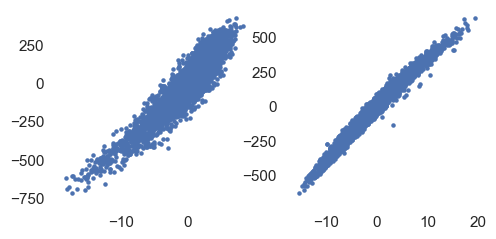

In [109]:
sel = lambda x: x.isel(time=slice(0, 480, 12)).transpose("time", "member")

fig, axs = plt.subplots(1, 2, figsize=(5.5, 2.5))

axs[0].scatter(
    sel(hw),
    sel(ohc_hw),
    s=5,
)

axs[1].scatter(
    sel(he),
    sel(ohc_he),
    s=5,
)

plt.show()

#### OHC vs $D_{20}$

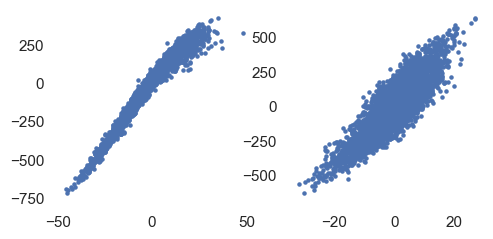

In [110]:
fig, axs = plt.subplots(1, 2, figsize=(5.5, 2.5))

axs[0].scatter(
    sel(hw_z20),
    sel(ohc_hw),
    s=5,
)

axs[1].scatter(
    sel(he_z20),
    sel(ohc_he),
    s=5,
)

plt.show()

#### SSH vs. $D_{20}$

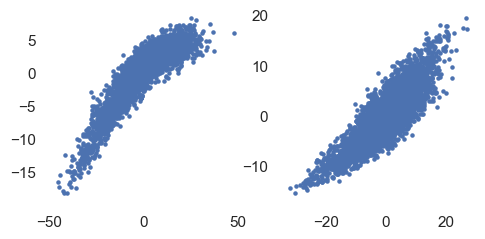

In [111]:
sel = lambda x: x.isel(time=slice(None, 480, 12)).transpose("time", "member")

fig, axs = plt.subplots(1, 2, figsize=(5.5, 2.5))

axs[0].scatter(
    sel(hw_z20),
    sel(hw),
    s=5,
)

axs[1].scatter(
    sel(he_z20),
    sel(he),
    s=5,
)

plt.show()

#### Seasonality

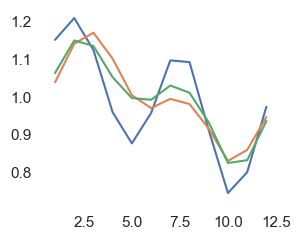

In [112]:
sel = lambda x: x.sel(time=slice(None, "1889"))
std_ = lambda x: sel(x).groupby("time.month").std(["time", "member"])
std = lambda x: std_(x) / sel(x).std(["time", "member"])

months = np.arange(1, 13)

## Plot
fig, ax = plt.subplots(figsize=(3, 2.5))
ax.plot(months, std(hw))
ax.plot(months, std(hw_z20))
ax.plot(months, std(ohc_hw))
# ax.plot(months, sel(hw_z20).groupby("time.month").std(["time","member"]))

## Sverdrup

In [113]:
T3 = src.utils.reconstruct_wrapper(
    anom[["sst", "sst_comp"]],
    src.utils.get_nino3,
)["sst"]

get_sub = lambda x: x.sel(z_t=slice(50, 80), longitude=slice(210, 270)).mean(
    ["longitude", "z_t"]
)
Tsub = src.utils.reconstruct_wrapper(anom_wide[["T", "T_comp"]], get_sub)["T"]

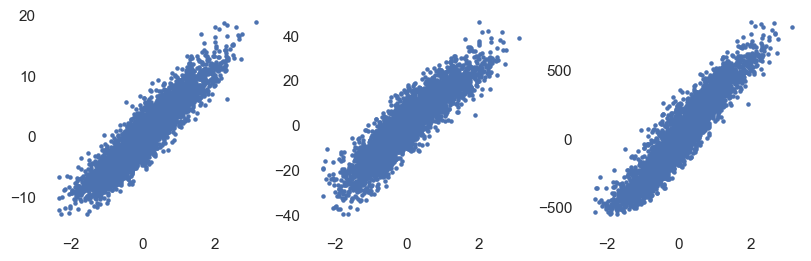

Tsub


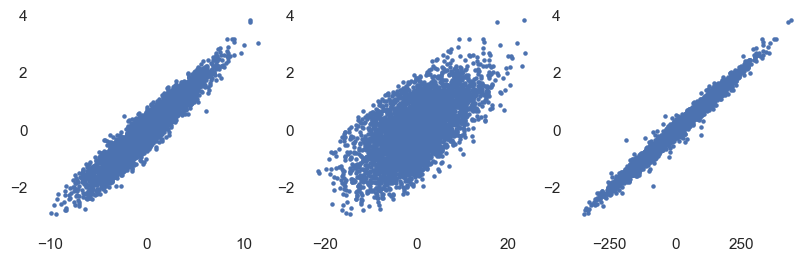

hw


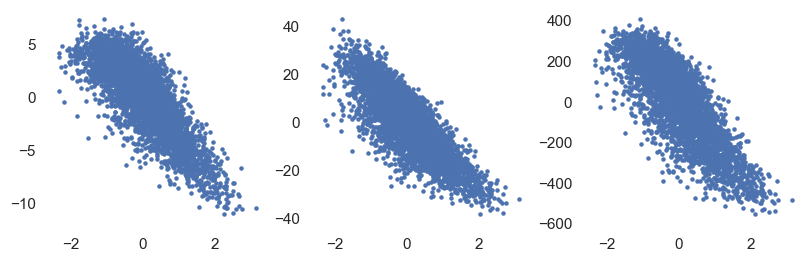

In [115]:
sel_ = lambda x: x.isel(time=slice(None, 480)).transpose("time", "member")
sel = lambda x: src.utils.sel_month(
    sel_(x).resample({"time": "QS-DEC"}).mean(),
    3,
)

fig, axs = plt.subplots(1, 3, figsize=(8, 2.5), layout="constrained")
axs[0].scatter(sel(T3), sel(he) - sel(hw), s=5)
axs[1].scatter(sel(T3), sel(he_z20) - sel(hw_z20), s=5)
axs[2].scatter(sel(T3), sel(ohc_he) - sel(ohc_hw), s=5)
plt.show()

print("Tsub")
fig, axs = plt.subplots(1, 3, figsize=(8, 2.5), layout="constrained")
axs[0].scatter(sel(he), sel(Tsub), s=5)
axs[1].scatter(sel(he_z20), sel(Tsub), s=5)
axs[2].scatter(sel(ohc_he), sel(Tsub), s=5)
plt.show()

print("hw")
fig, axs = plt.subplots(1, 3, figsize=(8, 2.5), layout="constrained")
axs[0].scatter(sel(T3), sel(hw), s=5)
axs[1].scatter(sel(T3), sel(hw_z20), s=5)
axs[2].scatter(sel(T3), sel(ohc_hw), s=5)
plt.show()